Using device: cuda

🔍 EfficientNet B0 Voting Metrics:
✅ Accuracy : 0.9393
✅ Precision: 0.9317
✅ Recall   : 0.9266
✅ F1 Score : 0.9273

🔍 Swin-Tiny Voting Metrics:
✅ Accuracy : 0.9422
✅ Precision: 0.9405
✅ Recall   : 0.9350
✅ F1 Score : 0.9362

🔍 ConvNeXt-Tiny Voting Metrics:
✅ Accuracy : 0.9217
✅ Precision: 0.9307
✅ Recall   : 0.8976
✅ F1 Score : 0.9074

🔍 Soft Ensemble Voting Metrics:
✅ Accuracy : 0.9583
✅ Precision: 0.9575
✅ Recall   : 0.9476
✅ F1 Score : 0.9512

🔍 Hard Ensemble Voting Metrics:
✅ Accuracy : 0.9525
✅ Precision: 0.9504
✅ Recall   : 0.9423
✅ F1 Score : 0.9453


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_17168\3826711693.py:123: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\STUDENT\anaconda\envs\pytorch_fin\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


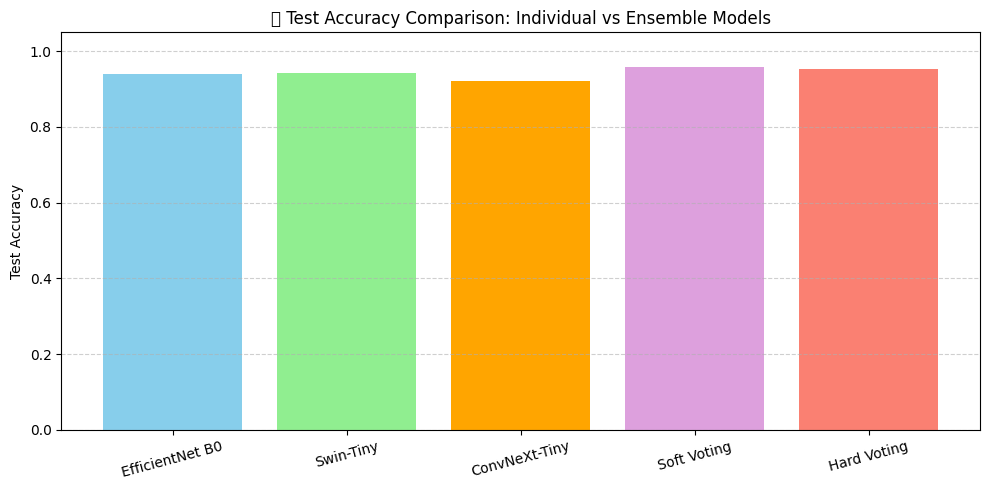

In [4]:
import os
import torch
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import mode
import matplotlib.pyplot as plt

# ==== Paths ====
test_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split\test"

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==== Transforms ====
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Test Dataset ====
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class_names = test_dataset.classes
num_classes = len(class_names)

# ==== Load Models ====
def load_model(arch, path):
    model = timm.create_model(arch, pretrained=False, num_classes=num_classes)
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

model_e = load_model('efficientnet_b0', 'final_efficientnet_model.pth')
model_s = load_model('swin_tiny_patch4_window7_224', 'final_swin_model.pth')
model_c = load_model('convnext_tiny', 'final_convnext_model.pth')

# ==== Get Predictions from Individual Model ====
def get_predictions(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

# ==== Ensemble Voting ====
all_soft_preds = []
all_hard_preds = []
y_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        y_true.extend(labels.cpu().numpy())

        probs_e = torch.softmax(model_e(inputs), dim=1).cpu().numpy()
        probs_s = torch.softmax(model_s(inputs), dim=1).cpu().numpy()
        probs_c = torch.softmax(model_c(inputs), dim=1).cpu().numpy()

        # Soft Voting
        avg_probs = (probs_e + probs_s + probs_c) / 3
        soft_preds = np.argmax(avg_probs, axis=1)
        all_soft_preds.extend(soft_preds)

        # Hard Voting
        preds_e = np.argmax(probs_e, axis=1)
        preds_s = np.argmax(probs_s, axis=1)
        preds_c = np.argmax(probs_c, axis=1)

        hard_preds = []
        for i in range(len(preds_e)):
            votes = [preds_e[i], preds_s[i], preds_c[i]]
            majority_vote = mode(votes, keepdims=True).mode[0]
            hard_preds.append(majority_vote)

        all_hard_preds.extend(hard_preds)

# ==== Metric Function ====
def compute_metrics(y_true, y_pred, method_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"\n🔍 {method_name} Voting Metrics:")
    print(f"✅ Accuracy : {acc:.4f}")
    print(f"✅ Precision: {prec:.4f}")
    print(f"✅ Recall   : {rec:.4f}")
    print(f"✅ F1 Score : {f1:.4f}")
    return acc

# ==== Individual Model Accuracies ====
y_true_e, y_pred_e = get_predictions(model_e, test_loader)
y_true_s, y_pred_s = get_predictions(model_s, test_loader)
y_true_c, y_pred_c = get_predictions(model_c, test_loader)

acc_e = compute_metrics(y_true_e, y_pred_e, "EfficientNet B0")
acc_s = compute_metrics(y_true_s, y_pred_s, "Swin-Tiny")
acc_c = compute_metrics(y_true_c, y_pred_c, "ConvNeXt-Tiny")

# ==== Ensemble Metrics ====
acc_soft = compute_metrics(y_true, all_soft_preds, "Soft Ensemble")
acc_hard = compute_metrics(y_true, all_hard_preds, "Hard Ensemble")

# ==== Bar Plot ====
methods = ['EfficientNet B0', 'Swin-Tiny', 'ConvNeXt-Tiny', 'Soft Voting', 'Hard Voting']
accs = [acc_e, acc_s, acc_c, acc_soft, acc_hard]

plt.figure(figsize=(10, 5))
plt.bar(methods, accs, color=['skyblue', 'lightgreen', 'orange', 'plum', 'salmon'])
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("📊 Test Accuracy Comparison: Individual vs Ensemble Models")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Using device: cuda

🔍 EfficientNet B0 Voting Metrics:
✅ Accuracy : 0.9393
✅ Precision: 0.9317
✅ Recall   : 0.9266
✅ F1 Score : 0.9273

🔍 Swin-Tiny Voting Metrics:
✅ Accuracy : 0.9422
✅ Precision: 0.9405
✅ Recall   : 0.9350
✅ F1 Score : 0.9362

🔍 ConvNeXt-Tiny Voting Metrics:
✅ Accuracy : 0.9342
✅ Precision: 0.9348
✅ Recall   : 0.9249
✅ F1 Score : 0.9256

🔍 Soft Ensemble Voting Metrics:
✅ Accuracy : 0.9554
✅ Precision: 0.9504
✅ Recall   : 0.9461
✅ F1 Score : 0.9471

🔍 Hard Ensemble Voting Metrics:
✅ Accuracy : 0.9539
✅ Precision: 0.9493
✅ Recall   : 0.9474
✅ F1 Score : 0.9475


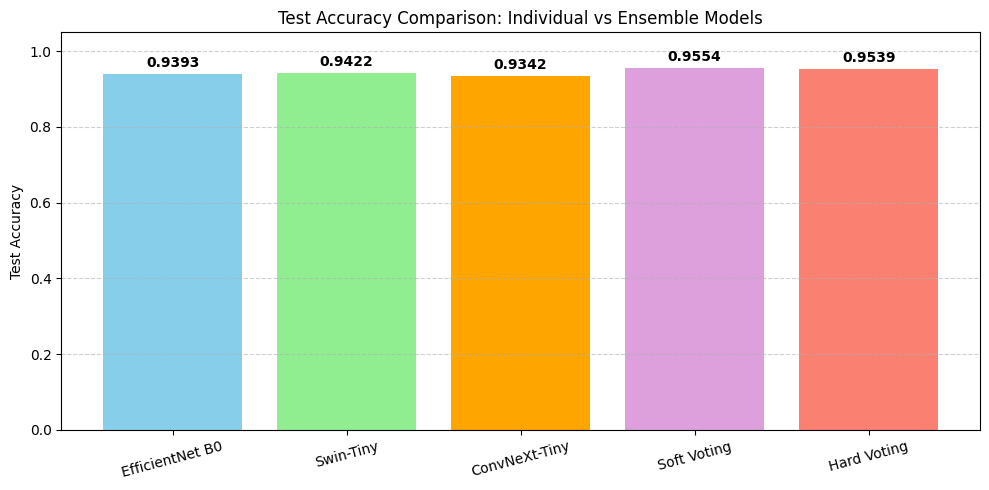

In [4]:
#ensemble models (cross entropy loss case)
import os
import torch
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import mode
import matplotlib.pyplot as plt

# ==== Paths ====
test_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split\test"

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==== Transforms ====
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Test Dataset ====
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class_names = test_dataset.classes
num_classes = len(class_names)

# ==== Load Models ====
def load_model(arch, path):
    model = timm.create_model(arch, pretrained=False, num_classes=num_classes)
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

model_e = load_model('efficientnet_b0', 'final_efficientnet_model.pth')
model_s = load_model('swin_tiny_patch4_window7_224', 'final_swin_model.pth')
model_c = load_model('convnext_tiny', 'final_convnext_model.pth')

# ==== Get Predictions from Individual Model ====
def get_predictions(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

# ==== Ensemble Voting ====
all_soft_preds = []
all_hard_preds = []
y_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        y_true.extend(labels.cpu().numpy())

        probs_e = torch.softmax(model_e(inputs), dim=1).cpu().numpy()
        probs_s = torch.softmax(model_s(inputs), dim=1).cpu().numpy()
        probs_c = torch.softmax(model_c(inputs), dim=1).cpu().numpy()

        # Soft Voting
        avg_probs = (probs_e + probs_s + probs_c) / 3
        soft_preds = np.argmax(avg_probs, axis=1)
        all_soft_preds.extend(soft_preds)

        # Hard Voting
        preds_e = np.argmax(probs_e, axis=1)
        preds_s = np.argmax(probs_s, axis=1)
        preds_c = np.argmax(probs_c, axis=1)

        hard_preds = []
        for i in range(len(preds_e)):
            votes = [preds_e[i], preds_s[i], preds_c[i]]
            majority_vote = mode(votes, keepdims=True).mode[0]
            hard_preds.append(majority_vote)

        all_hard_preds.extend(hard_preds)

# ==== Metric Function ====
def compute_metrics(y_true, y_pred, method_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"\n🔍 {method_name} Voting Metrics:")
    print(f"✅ Accuracy : {acc:.4f}")
    print(f"✅ Precision: {prec:.4f}")
    print(f"✅ Recall   : {rec:.4f}")
    print(f"✅ F1 Score : {f1:.4f}")
    return acc

# ==== Individual Model Accuracies ====
y_true_e, y_pred_e = get_predictions(model_e, test_loader)
y_true_s, y_pred_s = get_predictions(model_s, test_loader)
y_true_c, y_pred_c = get_predictions(model_c, test_loader)

acc_e = compute_metrics(y_true_e, y_pred_e, "EfficientNet B0")
acc_s = compute_metrics(y_true_s, y_pred_s, "Swin-Tiny")
acc_c = compute_metrics(y_true_c, y_pred_c, "ConvNeXt-Tiny")

# ==== Ensemble Metrics ====
acc_soft = compute_metrics(y_true, all_soft_preds, "Soft Ensemble")
acc_hard = compute_metrics(y_true, all_hard_preds, "Hard Ensemble")
# ==== Bar Plot with Accuracy Labels ====
methods = ['EfficientNet B0', 'Swin-Tiny', 'ConvNeXt-Tiny', 'Soft Voting', 'Hard Voting']
accs = [acc_e, acc_s, acc_c, acc_soft, acc_hard]

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, accs, color=['skyblue', 'lightgreen', 'orange', 'plum', 'salmon'])
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison: Individual vs Ensemble Models")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15)

# === Add Accuracy Values Above Bars ===
for bar, acc in zip(bars, accs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{acc:.4f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Using device: cuda

🔍 EfficientNet B0 Voting Metrics:
✅ Accuracy : 0.9254
✅ Precision: 0.9131
✅ Recall   : 0.9135
✅ F1 Score : 0.9111

🔍 Swin-Tiny Voting Metrics:
✅ Accuracy : 0.9232
✅ Precision: 0.9141
✅ Recall   : 0.9249
✅ F1 Score : 0.9171

🔍 ConvNeXt-Tiny Voting Metrics:
✅ Accuracy : 0.9532
✅ Precision: 0.9477
✅ Recall   : 0.9485
✅ F1 Score : 0.9470

🔍 Soft Ensemble Voting Metrics:
✅ Accuracy : 0.9612
✅ Precision: 0.9557
✅ Recall   : 0.9557
✅ F1 Score : 0.9547

🔍 Hard Ensemble Voting Metrics:
✅ Accuracy : 0.9525
✅ Precision: 0.9448
✅ Recall   : 0.9459
✅ F1 Score : 0.9441


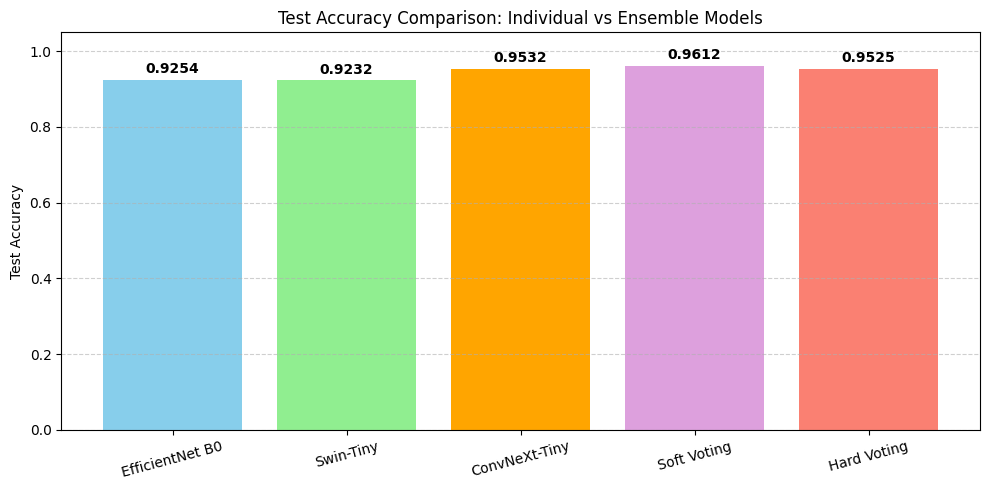

In [1]:
#ensembling model(focal loss case)
import os
import torch
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import mode
import matplotlib.pyplot as plt

# ==== Paths ====
test_dir = r"C:\Users\STUDENT\Downloads\FishDataset_Split\test"

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==== Transforms ====
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Test Dataset ====
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class_names = test_dataset.classes
num_classes = len(class_names)

# ==== Load Models ====
def load_model(arch, path):
    model = timm.create_model(arch, pretrained=False, num_classes=num_classes)
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

model_e = load_model('efficientnet_b0', 'final_efficientnet_model(focal).pth')
model_s = load_model('swin_tiny_patch4_window7_224', 'final_swin_model(focal).pth')
model_c = load_model('convnext_tiny', 'final_convnext_model(focal).pth')

# ==== Get Predictions from Individual Model ====
def get_predictions(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

# ==== Ensemble Voting ====
all_soft_preds = []
all_hard_preds = []
y_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        y_true.extend(labels.cpu().numpy())

        probs_e = torch.softmax(model_e(inputs), dim=1).cpu().numpy()
        probs_s = torch.softmax(model_s(inputs), dim=1).cpu().numpy()
        probs_c = torch.softmax(model_c(inputs), dim=1).cpu().numpy()

        # Soft Voting
        avg_probs = (probs_e + probs_s + probs_c) / 3
        soft_preds = np.argmax(avg_probs, axis=1)
        all_soft_preds.extend(soft_preds)

        # Hard Voting
        preds_e = np.argmax(probs_e, axis=1)
        preds_s = np.argmax(probs_s, axis=1)
        preds_c = np.argmax(probs_c, axis=1)

        hard_preds = []
        for i in range(len(preds_e)):
            votes = [preds_e[i], preds_s[i], preds_c[i]]
            majority_vote = mode(votes, keepdims=True).mode[0]
            hard_preds.append(majority_vote)

        all_hard_preds.extend(hard_preds)

# ==== Metric Function ====
def compute_metrics(y_true, y_pred, method_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"\n🔍 {method_name} Voting Metrics:")
    print(f"✅ Accuracy : {acc:.4f}")
    print(f"✅ Precision: {prec:.4f}")
    print(f"✅ Recall   : {rec:.4f}")
    print(f"✅ F1 Score : {f1:.4f}")
    return acc

# ==== Individual Model Accuracies ====
y_true_e, y_pred_e = get_predictions(model_e, test_loader)
y_true_s, y_pred_s = get_predictions(model_s, test_loader)
y_true_c, y_pred_c = get_predictions(model_c, test_loader)

acc_e = compute_metrics(y_true_e, y_pred_e, "EfficientNet B0")
acc_s = compute_metrics(y_true_s, y_pred_s, "Swin-Tiny")
acc_c = compute_metrics(y_true_c, y_pred_c, "ConvNeXt-Tiny")

# ==== Ensemble Metrics ====
acc_soft = compute_metrics(y_true, all_soft_preds, "Soft Ensemble")
acc_hard = compute_metrics(y_true, all_hard_preds, "Hard Ensemble")
# ==== Bar Plot with Accuracy Labels ====
methods = ['EfficientNet B0', 'Swin-Tiny', 'ConvNeXt-Tiny', 'Soft Voting', 'Hard Voting']
accs = [acc_e, acc_s, acc_c, acc_soft, acc_hard]

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, accs, color=['skyblue', 'lightgreen', 'orange', 'plum', 'salmon'])
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison: Individual vs Ensemble Models")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15)

# === Add Accuracy Values Above Bars ===
for bar, acc in zip(bars, accs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{acc:.4f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
